# Exploratory Data Analysis

This notebook looks at `combined_output.csv` (the merged table produced by **Estimator_Sheet.ipynb**)
before it goes into estimation. It's focused on the things that matter most for that step:

1. **Reality checks** — whether the project timeline dates (`construction_start_date`,
   `date_open_planned`/`date_open_actual`, `date_horizon`) are in a sane order.
2. **Peak hour volume & capacity** — how `peak_hour_volume` compares to `peak_hour_capacity`, and
   where volume exceeds capacity.
3. **Before vs. after** — how traffic counts, peak-hour volume, and peak-hour capacity change once a
   project opens.
4. **Before vs. after summary tables and charts**

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##   copy into terminal "pip install reportlab" if you don't have it already

from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib import colors as rl_colors
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (9, 5)

OUT_DIR    = r"C:\Users\User\Documents\Code\forecastcards_v2\forecastcards\notebooks\outputs"
TABLES_DIR = os.path.join(OUT_DIR, "tables")
GRAPHS_DIR = os.path.join(OUT_DIR, "graphs")
for sub in ['', 'projects', 'eda_project_timeseries', 'eda_vc_ratio']:
    os.makedirs(os.path.join(GRAPHS_DIR, sub), exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

_pdf_base_styles = getSampleStyleSheet()

def _pdf_fmt(v):
    """Format one cell value for a PDF table."""
    if pd.isna(v):
        return '-'
    if isinstance(v, (bool, np.bool_)):
        return str(v)
    if isinstance(v, (int, np.integer)):
        return f'{v:,}'
    if isinstance(v, (float, np.floating)):
        return f'{v:,.0f}' if float(v).is_integer() else f'{v:,.1f}'
    return str(v)

def save_table(t, name, index=True, title=None):
    """Render a DataFrame (plain or with a MultiIndex on rows and/or columns) as a PDF table under TABLES_DIR.
    Every cell is wrapped in a Paragraph so long text and many columns wrap instead of overflowing."""
    df = t.copy()
    name = os.path.splitext(name)[0] + '.pdf'
    path = os.path.join(TABLES_DIR, name)
    if title is None:
        title = os.path.splitext(name)[0].replace('_', ' ')

    n_idx = df.index.nlevels if index else 0
    idx_names = [n or '' for n in (df.index.names if index else [])]
    col_is_multi = isinstance(df.columns, pd.MultiIndex)
    if col_is_multi:
        top, sub = [c[0] for c in df.columns], [c[1] for c in df.columns]
        header_rows = 2
    else:
        sub, header_rows = [str(c) for c in df.columns], 1

    n_cols = n_idx + len(sub)
    font_size = 8 if n_cols <= 8 else (7 if n_cols <= 13 else 6)
    hdr_style = ParagraphStyle('hdr', parent=_pdf_base_styles['Normal'], fontName='Helvetica-Bold',
                               fontSize=font_size, leading=font_size + 2, alignment=1)
    idx_style = ParagraphStyle('idx', parent=_pdf_base_styles['Normal'], fontName='Helvetica',
                               fontSize=font_size, leading=font_size + 2, alignment=0)
    data_style = ParagraphStyle('data', parent=_pdf_base_styles['Normal'], fontName='Helvetica',
                                fontSize=font_size, leading=font_size + 2, alignment=1)
    P = lambda text, style: Paragraph(str(text), style)

    rows_raw, rows, span_cmds = [], [], []
    if col_is_multi:
        row0_raw = list(idx_names) + list(top)
        row1_raw = [''] * n_idx + list(sub)
        rows_raw += [row0_raw, row1_raw]
        rows += [[P(v, hdr_style) for v in row0_raw], [P(v, hdr_style) for v in row1_raw]]
        c = n_idx
        while c < len(row0_raw):
            c2 = c
            while c2 + 1 < len(row0_raw) and row0_raw[c2 + 1] == row0_raw[c]:
                c2 += 1
            if c2 > c:
                span_cmds.append(('SPAN', (c, 0), (c2, 0)))
            c = c2 + 1
        for i in range(n_idx):
            span_cmds.append(('SPAN', (i, 0), (i, 1)))
    else:
        row0_raw = list(idx_names) + list(sub)
        rows_raw.append(row0_raw)
        rows.append([P(v, hdr_style) for v in row0_raw])

    idx_vals = df.index.tolist() if n_idx else []
    for ridx, (_, r) in enumerate(df.iterrows()):
        if n_idx == 0:
            idx_raw, idx_part = [], []
        elif n_idx == 1:
            idx_raw = [str(idx_vals[ridx])]; idx_part = [P(idx_raw[0], idx_style)]
        else:
            idx_raw = [str(v) for v in idx_vals[ridx]]; idx_part = [P(v, idx_style) for v in idx_raw]
        data_raw = [_pdf_fmt(v) for v in r.tolist()]
        rows_raw.append(idx_raw + data_raw)
        rows.append(idx_part + [P(v, data_style) for v in data_raw])

    page = landscape(letter) if n_cols > 5 else letter
    margin = 0.4 * inch
    avail_w = page[0] - 2 * margin
    raw_len = [max(len(str(cell)) for cell in [r[c] if c < len(r) else '' for r in rows_raw]) for c in range(n_cols)]
    weight = [min(l, 40) ** 0.5 for l in raw_len]
    col_widths = [max(0.45 * inch, avail_w * w / sum(weight)) for w in weight]
    scale = avail_w / sum(col_widths)
    if scale < 1:
        col_widths = [w * scale for w in col_widths]

    elems = [Paragraph(title, _pdf_base_styles['Heading3']), Spacer(1, 6)]
    tbl = Table(rows, colWidths=col_widths, repeatRows=header_rows)
    tbl.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, header_rows - 1), rl_colors.HexColor('#dbe7f3')),
        ('GRID', (0, 0), (-1, -1), 0.4, rl_colors.grey),
        ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'),
        ('ROWBACKGROUNDS', (0, header_rows), (-1, -1), [rl_colors.white, rl_colors.HexColor('#f2f6fa')]),
        ('TOPPADDING', (0, 0), (-1, -1), 3), ('BOTTOMPADDING', (0, 0), (-1, -1), 3),
        ('LEFTPADDING', (0, 0), (-1, -1), 4), ('RIGHTPADDING', (0, 0), (-1, -1), 4),
    ] + span_cmds))
    elems.append(tbl)
    SimpleDocTemplate(path, pagesize=page, leftMargin=margin, rightMargin=margin,
                      topMargin=margin, bottomMargin=margin).build(elems)

def save_fig(fig, name, subdir=None):
    """Save a matplotlib figure as a (vector) PDF under GRAPHS_DIR."""
    name = os.path.splitext(name)[0] + '.pdf'
    path = os.path.join(GRAPHS_DIR, subdir, name) if subdir else os.path.join(GRAPHS_DIR, name)
    fig.savefig(path, bbox_inches='tight', facecolor='white')

def save_and_close(fig, name, subdir=None):
    """Save a figure without displaying it (used for sections with more than one graph)."""
    save_fig(fig, name, subdir)
    plt.close(fig)


## 1. Load the data

This is the same `combined_output.csv` that `Estimator_Sheet.ipynb` writes out, and that
`forecastcards.Dataset` would otherwise merge from cards directly. Point `DATA_PATH` at your own
file if it lives somewhere else.

In [2]:
DATA_PATH = r"C:\Users\User\Documents\Code\forecastcards_ba_data\data\combined_output.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"{df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

7284 rows, 49 columns


,project_id,state,county,project_type,description,date_open_planned,date_horizon,construction_start_date,date_open_actual,area_type,project_length_miles,poi_id,before_or_after,facility_name,segment_length_miles,speed_limit,lane_width,signals_per_mile,stop_signs_per_mile,through_lanes,left_turn_lanes,right_turn_lanes,express_hov_hot_lanes,shoulder_width,functional_class,obs_id,observation_date,start_time_observation,end_time_observation,observation_variable,observation_value,observation_unit,before_or_after_binary,date_open_effective,years_from_open,k_factor,d_factor,population,employment,avg annual pay,gasoline price,diesel price,cpi adjustment factor (to 2025$),avg annual pay (2025$),gasoline price (2025$),diesel price (2025$),peak_hour_volume,peak_hour_capacity,comment
0,237506-2,FL,Brevard,capacity expansion,"Banana River along S.R. 520, beginning at Mil...",2003-01-01,1/1/2023,unknown,2007-01-01,urban,0.6,701007,before,S.R. 520,13.108,55.0,10.0,0.0,0.0,4.0,0.0,0.0,0.0,6.0,principal arterial,701007_1,1997-01-01,0:00:00,24:00:00,volume,29800,AADT,0,2007-01-01,-10.0,0.12,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2145.6,3446.425171,NaN
1,237506-2,FL,Brevard,capacity expansion,"Banana River along S.R. 520, beginning at Mil...",2003-01-01,1/1/2023,unknown,2007-01-01,urban,0.6,701007,before,S.R. 520,13.108,55.0,10.0,0.0,0.0,4.0,0.0,0.0,0.0,6.0,principal arterial,701007_2,1998-01-01,0:00:00,24:00:00,volume,30500,AADT,0,2007-01-01,-9.0,0.12,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2196.0,3446.425171,NaN
2,237506-2,FL,Brevard,capacity expansion,"Banana River along S.R. 520, beginning at Mil...",2003-01-01,1/1/2023,unknown,2007-01-01,urban,0.6,701007,before,S.R. 520,13.108,55.0,10.0,0.0,0.0,4.0,0.0,0.0,0.0,6.0,principal arterial,701007_3,1999-01-01,0:00:00,24:00:00,volume,30100,AADT,0,2007-01-01,-8.0,0.12,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2167.2,3446.425171,NaN
3,237506-2,FL,Brevard,capacity expansion,"Banana River along S.R. 520, beginning at Mil...",2003-01-01,1/1/2023,unknown,2007-01-01,urban,0.6,701007,before,S.R. 520,13.108,55.0,10.0,0.0,0.0,4.0,0.0,0.0,0.0,6.0,principal arterial,701007_4,2000-01-01,0:00:00,24:00:00,volume,30500,AADT,0,2007-01-01,-7.0,0.12,0.6,477819.0,180459.0,32080.0,1.5285,1.374643,1.869588,59976.37,2.86,2.57,2196.0,3446.425171,NaN
4,237506-2,FL,Brevard,capacity expansion,"Banana River along S.R. 520, beginning at Mil...",2003-01-01,1/1/2023,unknown,2007-01-01,urban,0.6,701007,before,S.R. 520,13.108,55.0,10.0,0.0,0.0,4.0,0.0,0.0,0.0,6.0,principal arterial,701007_5,2001-01-01,0:00:00,24:00:00,volume,30500,AADT,0,2007-01-01,-6.0,0.12,0.6,486429.0,184725.0,32798.0,1.4720,1.279747,1.817860,59622.17,2.68,2.33,2196.0,3446.425171,NaN


In [3]:
df_raw.dtypes

project_id                              str
state                                   str
county                                  str
project_type                            str
description                             str
date_open_planned                       str
date_horizon                            str
construction_start_date                 str
date_open_actual                        str
area_type                               str
project_length_miles                float64
poi_id                                  str
before_or_after                         str
facility_name                           str
segment_length_miles                float64
speed_limit                         float64
lane_width                          float64
signals_per_mile                    float64
stop_signs_per_mile                 float64
through_lanes                       float64
left_turn_lanes                     float64
right_turn_lanes                    float64
express_hov_hot_lanes           

## 2. Basic cleaning

Just enough cleaning to make the numeric and date columns usable below. Some rows have the literal
string `"unknown"` instead of a number or a blank in `peak_hour_capacity` / `peak_hour_volume`, which
forces those columns to `object` dtype until it's fixed. The date columns are parsed here too, since
the reality checks in section 4 depend on them.

In [4]:
df = df_raw.copy()

numeric_cols = ['observation_value', 'peak_hour_volume', 'peak_hour_capacity']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c].astype(str).replace('unknown', np.nan), errors='coerce') \
        if df[c].dtype == object else df[c]

date_cols = ['construction_start_date', 'date_open_planned', 'date_open_actual',
             'date_horizon', 'observation_date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df[numeric_cols].dtypes

C:\Users\User\AppData\Local\Temp\ipykernel_24968\3254216807.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')


observation_value       int64
peak_hour_volume      float64
peak_hour_capacity    float64
dtype: object

## 3. Reality checks — project timeline dates

A handful of sanity checks on the project-level dates, since these are set independently when cards
are filled in and nothing stops them from being entered out of order:

- **Construction shouldn't start after the project opens.** `construction_start_date` later than the
  open date (actual if known, otherwise planned) means one of the two was mistyped.
- **A project shouldn't open after its own forecast horizon.** `date_horizon` is the year the
  forecast is meant to represent, so an open date after that year doesn't make sense.
- **Construction shouldn't start after the forecast horizon** either, for the same reason.
- **Observations should fall on the right side of the open date.** A row labeled `before` should have
  an `observation_date` earlier than the open date; a row labeled `after` should have one later.

In [5]:
project_dates = df[['project_id', 'construction_start_date', 'date_open_planned',
                     'date_open_actual', 'date_horizon']].drop_duplicates(subset='project_id').copy()

# use the actual open date where it's known, otherwise fall back to the planned date
project_dates['date_open_best'] = project_dates['date_open_actual'].fillna(project_dates['date_open_planned'])

project_dates['flag_construction_after_open'] = (
    project_dates['construction_start_date'] > project_dates['date_open_best'])
project_dates['flag_open_after_horizon'] = (
    project_dates['date_open_best'] > project_dates['date_horizon'])
project_dates['flag_construction_after_horizon'] = (
    project_dates['construction_start_date'] > project_dates['date_horizon'])

reality_flags = ['flag_construction_after_open', 'flag_open_after_horizon', 'flag_construction_after_horizon']
project_dates[reality_flags].sum().to_frame('n_projects_flagged')

,n_projects_flagged
flag_construction_after_open,0
flag_open_after_horizon,0
flag_construction_after_horizon,0


In [6]:
flagged_dates = project_dates.loc[
    project_dates[reality_flags].any(axis=1),
    ['project_id', 'construction_start_date', 'date_open_planned', 'date_open_actual',
     'date_horizon'] + reality_flags
]
save_table(flagged_dates, 'eda_reality_check_flags.csv', index=False)
flagged_dates

,project_id,construction_start_date,date_open_planned,date_open_actual,date_horizon,flag_construction_after_open,flag_open_after_horizon,flag_construction_after_horizon


In [7]:
df['date_open_best'] = df['date_open_actual'].fillna(df['date_open_planned'])

df['years_from_open'] = df['observation_date'].dt.year - df['date_open_best'].dt.year

flag_before_after_mismatch = (
    ((df['before_or_after'] == 'before') & (df['observation_date'] > df['date_open_best'])) |
    ((df['before_or_after'] == 'after') & (df['observation_date'] < df['date_open_best']))
)

print(f"{flag_before_after_mismatch.sum()} of {df['observation_date'].notna().sum()} observations "
      "are labeled before/after but observation_date doesn't match the open date")
df.loc[flag_before_after_mismatch,
       ['project_id', 'poi_id', 'obs_id', 'before_or_after', 'observation_date',
        'date_open_planned', 'date_open_actual']].head(20)

0 of 7284 observations are labeled before/after but observation_date doesn't match the open date


,project_id,poi_id,obs_id,before_or_after,observation_date,date_open_planned,date_open_actual


## 4. Peak hour volume vs. capacity

Peak-hour volume should not exceed peak-hour capacity (capacity is the theoretical maximum
throughput for the roadway), so a value above that line means either the volume, the capacity inputs
(`through_lanes`, `functional_class` lookup), or the HCM calculation itself has a problem.

In [8]:
df[['peak_hour_volume', 'peak_hour_capacity']].describe().T[['count', 'mean', '50%', 'min', 'max']]

,count,mean,50%,min,max
peak_hour_volume,4897.0,1916.587033,1235.190000,3.600000,13526.208000
peak_hour_capacity,5307.0,3175.853899,3102.899305,590.394663,10302.849214


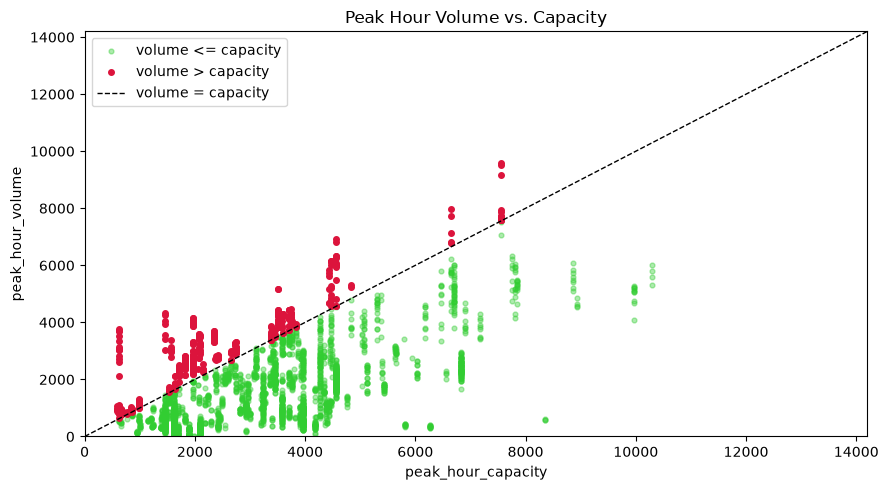

445 of 7284 rows have volume > capacity


In [9]:
over_capacity = df['peak_hour_volume'] > df['peak_hour_capacity']

fig, ax = plt.subplots()
ax.scatter(df.loc[~over_capacity, 'peak_hour_capacity'], df.loc[~over_capacity, 'peak_hour_volume'],
           s=12, color='limegreen', alpha=.4, label='volume <= capacity')
ax.scatter(df.loc[over_capacity, 'peak_hour_capacity'], df.loc[over_capacity, 'peak_hour_volume'],
           s=16, color='crimson', label='volume > capacity')
lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity'); ax.set_ylabel('peak_hour_volume')
ax.legend()
ax.set_title('Peak Hour Volume vs. Capacity')
plt.tight_layout()
save_fig(fig, 'eda_4_peak_volume_vs_capacity.png')
plt.show()

print(f"{over_capacity.sum()} of {len(df)} rows have volume > capacity")

## 5. Peak hour volume vs. capacity - before and after

The same volume-vs-capacity picture as section 4, but split by `before_or_after` so you can see how
observations move relative to the capacity line once a project opens. Points that cross from below
the `volume = capacity` line (before) to above it (after) are the ones worth a
second look.

In [10]:
fig, ax = plt.subplots()

colors = {'before': 'steelblue', 'after': 'darkorange'}
for stage, color in colors.items():
    sub = df[df['before_or_after'] == stage]
    ax.scatter(sub['peak_hour_capacity'], sub['peak_hour_volume'],
               s=14, alpha=.5, color=color, label=stage)

lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity')
ax.set_ylabel('peak_hour_volume')
ax.legend(title='before_or_after')
ax.set_title('Peak Hour Volume vs. Capacity (Before and After)')
plt.tight_layout()
save_and_close(fig, 'eda_5a_peak_volume_vs_capacity_before_and_after.png')

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = {'before': 'steelblue'}
for stage, color in colors.items():
    sub = df[df['before_or_after'] == stage]
    ax.scatter(sub['peak_hour_capacity'], sub['peak_hour_volume'],
               s=14, alpha=.5, color=color, label=stage)

lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity')
ax.set_ylabel('peak_hour_volume')
ax.legend(title='before_or_after')
ax.set_title('Peak Hour Volume vs. Capacity (Before)')
plt.tight_layout()
save_and_close(fig, 'eda_5b_peak_volume_vs_capacity_before.png')

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = {'after': 'darkorange'}
for stage, color in colors.items():
    sub = df[df['before_or_after'] == stage]
    ax.scatter(sub['peak_hour_capacity'], sub['peak_hour_volume'],
               s=14, alpha=.5, color=color, label=stage)

lims = [0, df[['peak_hour_capacity', 'peak_hour_volume']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='volume = capacity')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('peak_hour_capacity')
ax.set_ylabel('peak_hour_volume')
ax.legend(title='before_or_after')
ax.set_title('Peak Hour Volume vs. Capacity (After)')
plt.tight_layout()
save_and_close(fig, 'eda_5c_peak_volume_vs_capacity_after.png')

## 6. Before vs. after — traffic counts

For a capacity project, `observation_value` (AADT) should generally be higher *after* the project
opens than *before*. Projects where the after-value is lower than the before-value aren't
necessarily wrong, but they're worth a manual look.

In [13]:
before_after = (
    df.groupby(['project_id', 'before_or_after'])['observation_value']
      .mean()
      .unstack()
)
before_after['pct_change'] = (before_after['after'] / before_after['before'] - 1) * 100
before_after = before_after.sort_values('pct_change')
save_table(before_after.reset_index(), 'eda_before_after_pct_change.csv', index=False)
before_after

before_or_after,after,before,pct_change
project_id,,,
FM-0907,4955.298851,12795.666667,-61.273617
6-333.15,1706.884615,3272.857143,-47.847262
F-M-0436,9400.814815,16579.666667,-43.299133
11-188.00,12774.000000,22305.739130,-42.732227
10-114.00,1130.600000,1897.500000,-40.416337
...,...,...,...
FM-1410,4076.333333,NaN,NaN
FM-1603,13985.350000,NaN,NaN
FM-1803,NaN,65311.447761,NaN


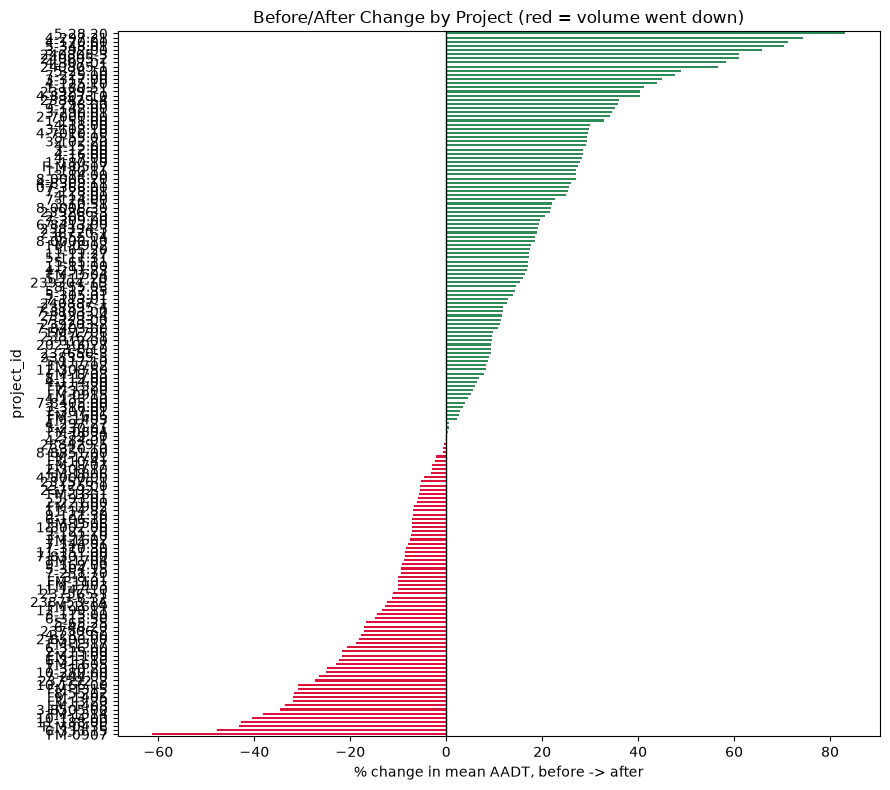

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_data = before_after['pct_change'].dropna()
colors = ['crimson' if v < 0 else 'seagreen' for v in plot_data]
plot_data.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('% change in mean AADT, before -> after')
ax.set_title('Before/After Change by Project (red = volume went down)')
plt.tight_layout()
save_fig(fig, 'eda_6_before_after_barh.png')
plt.show()

## 7. Traffic counts, peak volume & capacity over time (per project)

For each project, this plots `observation_value` (AADT), `peak_hour_volume`, and `peak_hour_capacity`
over calendar year, with one line per count station (`poi_id`) for each metric. A vertical dashed line
marks the year the project actually opened (`date_open_actual`).

**Note on scale:** `observation_value` is a full-day count (AADT) while `peak_hour_volume` and
`peak_hour_capacity` are single-hour figures, so they sit on a much smaller scale and will look
close to flat at the bottom of the chart next to the AADT line for the same station.

One chart per project — saved to `graphs/eda_project_timeseries/`, not displayed here.

In [15]:
def plot_project_station_timeseries(df, project_id, ax=None):
    """Line chart for one project: AADT, peak-hour volume, and peak-hour capacity per
    count station (poi_id), plotted against calendar year. Draws a vertical line at the
    project's actual open year."""
    proj = df[(df['project_id'] == project_id) & df['observation_date'].notna()].copy()
    if proj.empty:
        print(f"No dated observations for {project_id}")
        return None
    proj['year'] = proj['observation_date'].dt.year

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    stations = sorted(proj['poi_id'].unique())
    cmap = plt.get_cmap('tab10')
    for i, poi in enumerate(stations):
        color = cmap(i % 10)
        sub = proj[proj['poi_id'] == poi].sort_values('year')
        yearly = sub.groupby('year')[['observation_value', 'peak_hour_volume', 'peak_hour_capacity']].mean()

        ax.plot(yearly.index, yearly['observation_value'], color=color, marker='o',
                linewidth=1.5, label=f'POI {poi} - AADT count')
        if yearly['peak_hour_volume'].notna().any():
            ax.plot(yearly.index, yearly['peak_hour_volume'], color=color, marker='s',
                    linestyle='--', alpha=.7, linewidth=1, label=f'POI {poi} - peak hr volume')
        if yearly['peak_hour_capacity'].notna().any():
            ax.plot(yearly.index, yearly['peak_hour_capacity'], color=color, linestyle=':',
                    alpha=.5, linewidth=1, label=f'POI {poi} - peak hr capacity')

    open_dates = proj['date_open_best'].dropna()
    if len(open_dates):
        open_year = open_dates.iloc[0].year
        ax.axvline(open_year, color='black', linestyle='--', linewidth=1.5, label=f'opened {open_year}')

    ax.set_xlabel('Year')
    ax.set_ylabel('AADT')
    ax.set_title(f'{project_id}: Traffic Counts, Peak Volume & Capacity by Station')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1))
    return ax

In [16]:
# Only plot projects whose observed count years actually span the opening year
def _spans_open_year(df, project_id):
    proj = df[(df['project_id'] == project_id) & df['observation_date'].notna()]
    if proj.empty:
        return False
    open_dates = proj['date_open_best'].dropna()
    if not len(open_dates):
        return False
    open_year = open_dates.iloc[0].year
    years = proj['observation_date'].dt.year
    return years.min() <= open_year <= years.max()

PROJECTS_TO_PLOT = [pid for pid in sorted(df['project_id'].dropna().unique()) if _spans_open_year(df, pid)]
print(f"{len(PROJECTS_TO_PLOT)} of {df['project_id'].nunique()} projects have counts spanning their opening year")

n_saved = 0
for pid in PROJECTS_TO_PLOT:
    fig, ax = plt.subplots(figsize=(10, 6))
    result = plot_project_station_timeseries(df, pid, ax=ax)
    if result is None:
        plt.close(fig)  # no data for this project - skip the chart
        continue
    plt.tight_layout()
    save_and_close(fig, f"eda_7_timeseries_{re.sub(r'[^A-Za-z0-9._-]', '_', str(pid))}.png", subdir='eda_project_timeseries')
    n_saved += 1
print(f'{n_saved} charts saved to {GRAPHS_DIR}\\eda_project_timeseries\\')

80 of 207 projects have counts spanning their opening year
80 charts saved to C:\Users\User\Documents\Code\forecastcards_v2\forecastcards\notebooks\outputs\graphs\eda_project_timeseries\


## 8. AADT vs. years from open (all projects)

The same traffic-count trend as section 7, but re-centered on each project's own opening year
(`years_from_open`) instead of the calendar year, and overlaid across all projects so their timelines
line up at the opening (`years_from_open = 0`, marked with the vertical dashed line). Each line is
one project's average AADT across its stations for that year offset.

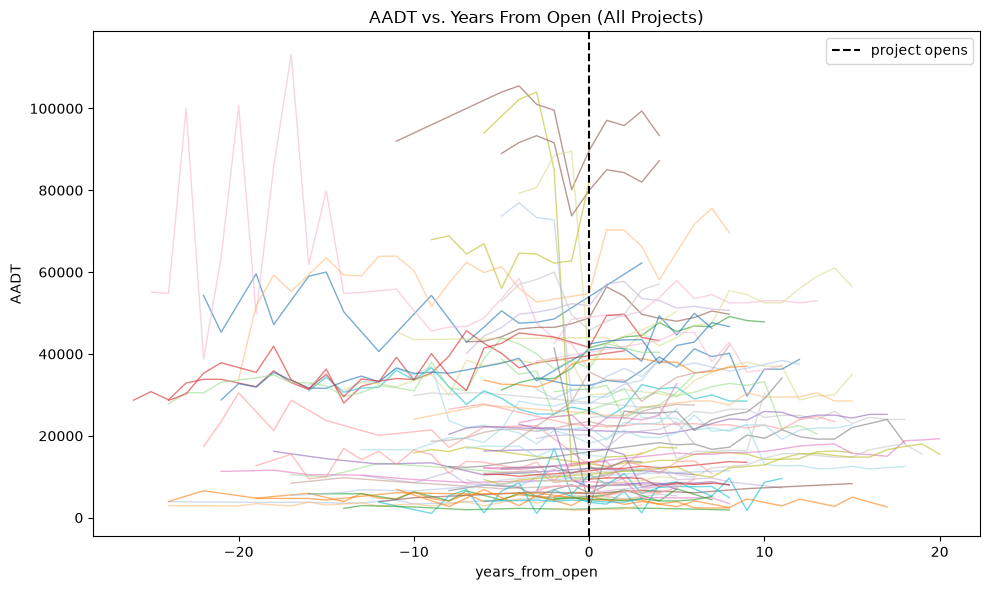

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

project_ids = [
    pid for pid in sorted(df['project_id'].dropna().unique())
    if (df.loc[df['project_id'] == pid, 'years_from_open'].min() <= 0
        <= df.loc[df['project_id'] == pid, 'years_from_open'].max())
]
cmap = plt.get_cmap('tab20')

for i, pid in enumerate(project_ids):
    sub = df[df['project_id'] == pid]
    yearly = sub.groupby('years_from_open')['observation_value'].mean().dropna()
    if len(yearly) < 2:
        continue
    ax.plot(yearly.index, yearly.values, color=cmap(i % 20), alpha=.6, linewidth=1)

ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='project opens')
ax.set_xlabel('years_from_open')
ax.set_ylabel('AADT')
ax.set_title('AADT vs. Years From Open (All Projects)')
ax.legend()
plt.tight_layout()
save_fig(fig, 'eda_8_aadt_vs_years_from_open.png')
plt.show()

## 9. % change in AADT vs. years from open (all projects)

Same idea as section 8, but each project's AADT is converted to a % change relative to its own
pre-project baseline (the average AADT across all observations with `years_from_open < 0`), so
projects with very different traffic volumes can be compared on the same y-axis. The vertical dashed
line marks the opening year; the horizontal line at 0% marks the baseline itself.

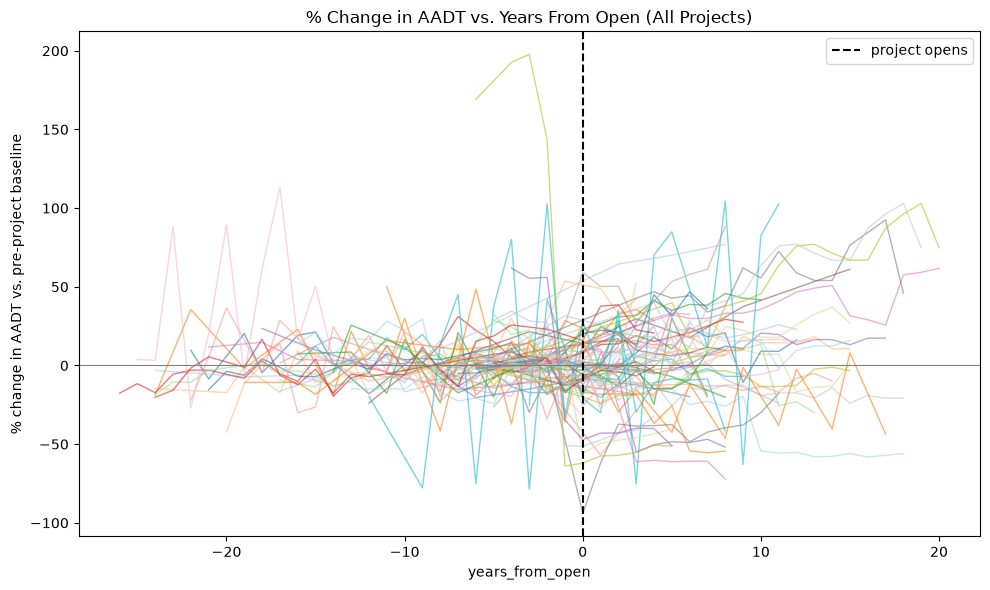

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, pid in enumerate(project_ids):
    sub = df[df['project_id'] == pid]
    yearly = sub.groupby('years_from_open')['observation_value'].mean().dropna()
    baseline = sub.loc[sub['years_from_open'] < 0, 'observation_value'].mean()
    if pd.isna(baseline) or baseline == 0 or len(yearly) < 2:
        continue
    pct = (yearly / baseline - 1) * 100
    ax.plot(pct.index, pct.values, color=cmap(i % 20), alpha=.6, linewidth=1)

ax.axhline(0, color='gray', linewidth=.8)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='project opens')
ax.set_xlabel('years_from_open')
ax.set_ylabel('% change in AADT vs. pre-project baseline')
ax.set_title('% Change in AADT vs. Years From Open (All Projects)')
ax.legend()
plt.tight_layout()
save_fig(fig, 'eda_9_pct_change_vs_years_from_open.png')
plt.show()

## 10. Volume-to-capacity ratio over time (per project)

For each project, plots `peak_hour_volume / peak_hour_capacity` over calendar year, with one line per
count station. A ratio above 1 (marked with the red dotted line) means the station's peak-hour volume
exceeds its computed peak-hour capacity.

One chart per project — saved to `graphs/eda_vc_ratio/`, not displayed here.

In [19]:
def plot_project_vc_ratio(df, project_id, ax=None):
    """Line chart for one project: volume/capacity ratio per count station (poi_id) over
    calendar year. Draws a vertical line at the project's actual open year and a horizontal
    reference line at ratio = 1 (volume = capacity)."""
    proj = df[(df['project_id'] == project_id) & df['observation_date'].notna()].copy()
    proj = proj.dropna(subset=['peak_hour_volume', 'peak_hour_capacity'])
    proj = proj[proj['peak_hour_capacity'] > 0]
    if proj.empty:
        print(f"No usable volume/capacity data for {project_id}")
        return None
    proj['year'] = proj['observation_date'].dt.year
    proj['vc_ratio'] = proj['peak_hour_volume'] / proj['peak_hour_capacity']

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    stations = sorted(proj['poi_id'].unique())
    cmap = plt.get_cmap('tab10')
    for i, poi in enumerate(stations):
        sub = proj[proj['poi_id'] == poi].sort_values('year')
        yearly = sub.groupby('year')['vc_ratio'].mean()
        ax.plot(yearly.index, yearly.values, color=cmap(i % 10), marker='o', label=f'POI {poi}')

    open_dates = proj['date_open_best'].dropna()
    if len(open_dates):
        open_year = open_dates.iloc[0].year
        ax.axvline(open_year, color='black', linestyle='--', linewidth=1.5, label=f'opened {open_year}')

    ax.axhline(1, color='crimson', linestyle=':', linewidth=1, label='volume = capacity')
    ax.set_xlabel('Year')
    ax.set_ylabel('Volume / Capacity')
    ax.set_title(f'{project_id}: Volume-to-Capacity Ratio by Station')
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
    return ax

In [20]:
n_saved = 0
for pid in PROJECTS_TO_PLOT:
    fig, ax = plt.subplots(figsize=(10, 6))
    result = plot_project_vc_ratio(df, pid, ax=ax)
    if result is None:
        plt.close(fig)  # no usable volume/capacity data for this project - skip the chart
        continue
    plt.tight_layout()
    save_and_close(fig, f"eda_10_vc_ratio_{re.sub(r'[^A-Za-z0-9._-]', '_', str(pid))}.png", subdir='eda_vc_ratio')
    n_saved += 1
print(f'{n_saved} charts saved to {GRAPHS_DIR}\\eda_vc_ratio\\')

No usable volume/capacity data for 20190058
No usable volume/capacity data for 240805-2
No usable volume/capacity data for 7-113.01
No usable volume/capacity data for FM-1803
76 charts saved to C:\Users\User\Documents\Code\forecastcards_v2\forecastcards\notebooks\outputs\graphs\eda_vc_ratio\



# Part 2: Before vs. After Traffic Count (AADT) Summary

Data-paper tables and charts modeled on Hoque et al. (2021), *The changing accuracy of traffic forecasts*. Compares
**average AADT in the N years before a project opens to the N years after**.

**Definition of change**
- The opening year is **excluded**. *Before* = mean AADT over years -N ... -1; *after* = mean AADT over years +1 ... +N. N = 3 and 5 are the main cases; 4 and 6 are shown for sensitivity.
- Only years with an actual observation are used. Each side's window average is the mean of whatever real counts fall in that N-year range (often fewer than N years).
- A station needs at least one real observation on a side to get a value for that side. Stations are averaged to a project (as in the paper), and change is computed per project:
  `absolute change = after - before`, `percent change = (after - before) / before * 100`.

Every table and graph in this notebook (Part 1 and Part 2) is saved under `before_after_outputs/` (see section 1): CSVs in `tables/`, PNGs in `graphs/` (per-project charts in their own subfolders). A section that produces more than one graph only saves them — it doesn't display them all inline — to keep this notebook readable; a section with a single graph still displays it as usual.

| Section | Output |
|---|---|
| 11 | Setup and settings |
| 12 | Load, clean, harmonize categories |
| 13 | Compute before/after change |
| 14 | Table 1: projects / segments / observations by state, type, etc. |
| 15 | Table 2: variables included and % of records with data |
| 16 | Count charts: when projects opened; overall change in counts (three layouts) |
| 17 | Table 3: change by dimension |
| 18 | Histograms of change |
| 19 | Per-project charts (supplemental) |
| 20 | Open questions, data flags, sensitivity |

## 11. Setup and settings

In [21]:
import warnings
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 200)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'axes.titleweight': 'bold'})

# OUT_DIR / TABLES_DIR / GRAPHS_DIR / save_table / save_fig / save_and_close are all defined once, in section 1.
WINDOWS   = [3, 4, 5, 6]            # N values computed
PRIMARY_N, SECONDARY_N = 5, 3       # N used for the main tables / charts
EXCLUDE_YEAR_BEFORE = False         # True = also drop the year before opening (construction impact) from the 'before' window
INFER_OPEN_YEAR     = False         # True = estimate open year for projects with no recorded open date (see section 20)
MIN_ACTUAL_OBS      = 1             # real (non-interpolated) count-years a station needs inside a window

## 12. Load, clean, and harmonize categories

Open date logic is the same as the EDA notebook: `date_open_actual` if known, otherwise `date_open_planned`
(this matches `date_open_effective`). `rel` is years from opening (`observation year - open year`).

In [22]:
FC_MAP = {'interstate': 'Interstate / freeway / expressway', 'freeway': 'Interstate / freeway / expressway',
          'principal arterial - other freeways and expressway': 'Interstate / freeway / expressway',
          'principal arterial': 'Principal arterial', 'principal arterial - other': 'Principal arterial',
          'principal arterials': 'Principal arterial', 'princicpal arterial': 'Principal arterial',
          'minor arterial': 'Minor arterial', 'major collector': 'Collector', 'minor collector': 'Collector',
          'ramp': 'Ramp', 'local': 'Local'}
FC_ORDER = ['Interstate / freeway / expressway', 'Principal arterial', 'Minor arterial', 'Collector', 'Ramp', 'Local', 'Unknown']
PT_MAP = {'Major Widen': 'Capacity expansion (widening)', 'Major Widening': 'Capacity expansion (widening)',
          'road-capacity-expansion': 'Capacity expansion (widening)', 'New Route': 'New roadway',
          'new-roadway': 'New roadway', 'Ichg Reconst': 'Interchange reconstruction'}
AT_MAP = {'Large Urbanized Area': 'Urban', 'Small Urbanized Area': 'Urban', 'Small Urban Area': 'Urban', 'urban': 'Urban',
          'suburban': 'Suburban / exurban', 'exurban': 'Suburban / exurban', 'Rural Area': 'Rural', 'rural': 'Rural',
          'Unknown': 'Unknown'}

def clean_fc(x):
    return 'Unknown' if pd.isna(x) else FC_MAP.get(str(x).strip().lower(), 'Unknown')

def open_period(y):
    if pd.isna(y): return 'No open date'
    y = int(y)
    return ('1999 or earlier' if y <= 1999 else '2000-2009' if y <= 2009 else '2010-2015' if y <= 2015
            else '2016-2019' if y <= 2019 else '2020 or later')
PERIOD_ORDER = ['1999 or earlier', '2000-2009', '2010-2015', '2016-2019', '2020 or later', 'No open date']

def load(path, infer_open_year=False):
    d = pd.read_csv(path)
    for c in ['date_open_planned', 'date_open_actual', 'date_horizon', 'date_open_effective',
              'construction_start_date', 'observation_date']:
        d[c] = pd.to_datetime(d[c], errors='coerce')
    d['year'] = d['observation_date'].dt.year
    d['open_date'] = d['date_open_actual'].fillna(d['date_open_planned'])
    d['open_year'] = d['open_date'].dt.year
    d['open_year_source'] = np.where(d['open_year'].notna(), 'recorded', 'none')
    if infer_open_year:
        # dated projects label the opening year 'before' and start 'after' at open year + 1, so the same rule is applied:
        # open year = (first year labeled 'after') - 1
        fa = d[d['before_or_after'] == 'after'].groupby('project_id')['year'].min() - 1
        m = d['open_year'].isna()
        d.loc[m, 'open_year'] = d.loc[m, 'project_id'].map(fa)
        d.loc[m & d['open_year'].notna(), 'open_year_source'] = 'inferred'
    d['rel'] = d['year'] - d['open_year']
    d['fc'] = d['functional_class'].map(clean_fc)
    d['ptype'] = d['project_type'].map(PT_MAP)
    d['atype'] = d['area_type'].map(AT_MAP)
    return d

ba_df = load(DATA_PATH, INFER_OPEN_YEAR)
print(f"{len(ba_df):,} AADT observations | {ba_df['project_id'].nunique()} projects | "
      f"{ba_df.groupby(['project_id','poi_id']).ngroups} segments (project x count location)")
assert (ba_df.loc[ba_df['open_year'].notna() & (ba_df['open_year_source']=='recorded'), 'open_year']
        == ba_df.loc[ba_df['open_year'].notna() & (ba_df['open_year_source']=='recorded'), 'date_open_effective'].dt.year).all()
print(ba_df[['state', 'ptype', 'atype', 'fc']].apply(lambda s: s.value_counts(dropna=False).to_dict()).to_string())

7,284 AADT observations | 207 projects | 697 segments (project x count location)
state    {'KY': 3669, 'MN': 1964, 'FL': 1244, 'NY': 257...
ptype    {'Capacity expansion (widening)': 4835, nan: 1...
atype    {'Rural': 3491, 'Urban': 2556, 'Suburban / exu...
fc       {'Unknown': 2930, 'Principal arterial': 1571, ...


In [23]:
def project_attributes(d):
    """One row per project. Facility type = the most common known functional class among the project's segments."""
    pa = d.groupby('project_id').agg(state=('state', 'first'), ptype=('ptype', 'first'), atype=('atype', 'first'),
                                     open_year=('open_year', 'first'), open_source=('open_year_source', 'first'),
                                     n_segments=('poi_id', 'nunique'), n_obs=('obs_id', 'size'))
    seg = d.drop_duplicates(['project_id', 'poi_id'])
    cnt = seg[seg['fc'] != 'Unknown'].groupby(['project_id', 'fc']).size().reset_index(name='n')
    cnt['rank'] = cnt['fc'].map({k: i for i, k in enumerate(FC_ORDER)})
    modal = (cnt.sort_values(['project_id', 'n', 'rank'], ascending=[True, False, True])
                .drop_duplicates('project_id').set_index('project_id')['fc'])
    pa['fc'] = modal.reindex(pa.index).fillna('Unknown')
    pa['period'] = pa['open_year'].map(open_period)
    return pa

proj_attr = project_attributes(ba_df)
proj_attr['period'].value_counts().reindex(PERIOD_ORDER)

period
1999 or earlier    21
2000-2009          18
2010-2015          17
2016-2019          30
2020 or later      26
No open date       95
Name: count, dtype: int64

## 13. Compute before / after change

For every count station (project x `poi_id`) we take the mean AADT in each real observation year, and average the years that fall inside
the N-year before/after windows. `stations` keeps every station; `station_ok` keeps those with
both sides; `projects` is the project-level result used everywhere below.

In [24]:
def station_window(g, N, offset):
    """g: one station's yearly rows (rel, val). Returns {side: (window mean, real obs in window, years in window)}.
    Uses only actual observation years that fall in the window — no interpolation, no fill."""
    out = {}
    for side, sign in (('before', -1), ('after', 1)):
        s = g[(g['rel'] * sign) > 0].set_index('rel')['val'].sort_index()
        lo, hi = (-(N + offset), -(1 + offset)) if side == 'before' else (1, N)
        win = s.loc[(s.index >= lo) & (s.index <= hi)]
        n_act = len(win)
        out[side] = (win.mean() if n_act >= MIN_ACTUAL_OBS else np.nan, n_act, n_act)
    return out

def station_years(d):
    """Yearly mean AADT per station, with years-from-open."""
    return (d[d['rel'].notna()].groupby(['project_id', 'poi_id', 'year', 'rel'], as_index=False)['observation_value']
              .mean().rename(columns={'observation_value': 'val'}))

def compute_changes(d, N, pa=None, exclude_year_before=None):
    pa = proj_attr if pa is None else pa
    offset = int(EXCLUDE_YEAR_BEFORE if exclude_year_before is None else exclude_year_before)
    rows = []
    for (pid, poi), g in station_years(d).groupby(['project_id', 'poi_id']):
        w = station_window(g, N, offset)
        rows.append(dict(project_id=pid, poi_id=poi, before=w['before'][0], after=w['after'][0],
                         obs_before=w['before'][1], obs_after=w['after'][1],
                         yrs_before=w['before'][2], yrs_after=w['after'][2]))
    stations = pd.DataFrame(rows)
    station_ok = stations.dropna(subset=['before', 'after']).copy()
    station_ok['abs_change'] = station_ok['after'] - station_ok['before']
    station_ok['pct_change'] = station_ok['abs_change'] / station_ok['before'] * 100
    projects = (station_ok.groupby('project_id')
                .agg(before=('before', 'mean'), after=('after', 'mean'), n_segments=('poi_id', 'nunique'),
                     obs_used=('obs_before', 'sum'), obs_used_after=('obs_after', 'sum'),
                     yrs_before=('yrs_before', 'mean'), yrs_after=('yrs_after', 'mean')).reset_index())
    projects['obs_used'] += projects.pop('obs_used_after')
    projects['abs_change'] = projects['after'] - projects['before']
    projects['pct_change'] = projects['abs_change'] / projects['before'] * 100
    projects = projects.merge(pa.drop(columns=['n_segments', 'n_obs']), left_on='project_id', right_index=True)
    station_ok = station_ok.merge(d.drop_duplicates(['project_id', 'poi_id'])[['project_id', 'poi_id', 'fc']],
                                  on=['project_id', 'poi_id'])
    return dict(stations=stations, station_ok=station_ok, projects=projects)

res = {N: compute_changes(ba_df, N) for N in WINDOWS}

def summarize(r, N):
    p, s = r['projects'], r['station_ok']
    return pd.Series({'N (years)': N, 'projects': len(p), 'segments': len(s),
                      'mean AADT before': p['before'].mean(), 'mean AADT after': p['after'].mean(),
                      'mean % change': p['pct_change'].mean(), 'median % change': p['pct_change'].median(),
                      '% projects up': (p['pct_change'] > 0).mean() * 100,
                      'avg yrs in before window': p['yrs_before'].mean(), 'avg yrs in after window': p['yrs_after'].mean()})
sens = pd.DataFrame([summarize(res[N], N) for N in WINDOWS]).set_index('N (years)')
save_table(sens.round(2), 'table0_overall_change_by_N.csv')
sens.round(1)

,projects,segments,mean AADT before,mean AADT after,mean % change,median % change,% projects up,avg yrs in before window,avg yrs in after window
N (years),,,,,,,,,
3.0,61.0,184.0,24806.1,26281.6,2.5,2.7,59.0,2.0,2.4
4.0,62.0,194.0,24811.4,26277.3,3.2,3.0,66.1,2.4,3.0
5.0,65.0,203.0,23984.3,25649.1,5.8,6.2,67.7,2.7,3.5
6.0,69.0,209.0,23926.8,25543.7,5.8,5.4,66.7,3.0,4.0


In [25]:
cov = res[PRIMARY_N]['station_ok']
cov_tab = pd.concat({'before window': cov['yrs_before'].value_counts().sort_index(),
                     'after window': cov['yrs_after'].value_counts().sort_index()}, axis=1).fillna(0).astype(int)
cov_tab.index.name = f'years covered (of N={PRIMARY_N})'
cov_tab['% of segments (before)'] = (cov_tab['before window'] / cov_tab['before window'].sum() * 100).round(1)
cov_tab['% of segments (after)'] = (cov_tab['after window'] / cov_tab['after window'].sum() * 100).round(1)
save_table(cov_tab, 'table0b_window_coverage.csv')
cov_tab

,before window,after window,% of segments (before),% of segments (after)
years covered (of N=5),,,,
1,52,22,25.6,10.8
2,49,29,24.1,14.3
3,25,25,12.3,12.3
4,16,27,7.9,13.3
5,61,100,30.0,49.3


## 14. Table 1 — Number of projects, segments, and observations

*Segment* = a count location (`poi_id`) within a project. The right block is the
**analysis sample** for the primary N: projects with a recorded open date and at least one segment that has AADT both before and
after opening. Facility type is a segment attribute, so a project can appear under more than one facility type there.

In [26]:
seg_all = ba_df.drop_duplicates(['project_id', 'poi_id'])[['project_id', 'poi_id', 'fc']]
def count_block(col, order, level='project'):
    """rows for one dimension. level='project': project attribute; level='segment': segment attribute (facility type)."""
    P = res[PRIMARY_N]['projects']; S = res[PRIMARY_N]['station_ok']
    rows = []
    for cat in order:
        if level == 'project':
            ids = proj_attr.index[proj_attr[col] == cat]
            n_seg = proj_attr.loc[ids, 'n_segments'].sum(); n_obs = proj_attr.loc[ids, 'n_obs'].sum()
            n_dated = (proj_attr.loc[ids, 'open_source'] != 'none').sum()
            pa_ = P[P[col] == cat]
            rows.append([cat, len(ids), n_seg, n_obs, n_dated, len(pa_), pa_['n_segments'].sum(), pa_['obs_used'].sum()])
        else:
            sub = ba_df[ba_df[col] == cat]; sseg = seg_all[seg_all[col] == cat]
            ids = sub['project_id'].unique()
            so = S[S[col] == cat]
            rows.append([cat, len(ids), len(sseg), len(sub), sub.loc[sub['open_source'] != 'none', 'project_id'].nunique()
                         if 'open_source' in sub else sub.loc[sub['open_year'].notna(), 'project_id'].nunique(),
                         so['project_id'].nunique(), len(so), np.nan])
    return rows

cols = ['Projects', 'Segments', 'AADT obs.', 'Projects w/ open date', 'Projects', 'Segments', 'AADT obs. used']
P = res[PRIMARY_N]['projects']
blocks = [('All', [['All data', len(proj_attr), proj_attr['n_segments'].sum(), proj_attr['n_obs'].sum(),
                    (proj_attr['open_source'] != 'none').sum(), len(P), P['n_segments'].sum(), P['obs_used'].sum()]]),
          ('State', count_block('state', ['KY', 'MN', 'NY', 'NH', 'NE'])),
          ('Project type', count_block('ptype', ['Capacity expansion (widening)', 'New roadway', 'Interchange reconstruction'])),
          ('Area type', count_block('atype', ['Urban', 'Suburban / exurban', 'Rural', 'Unknown'])),
          ('Opening period', count_block('period', PERIOD_ORDER)),
          ('Facility type (segment level)', count_block('fc', FC_ORDER, level='segment'))]
rows, idx = [], []
for head, rr in blocks:
    for r in rr:
        idx.append((head, r[0])); rows.append(r[1:])
table1 = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(idx, names=['Dimension', 'Category']),
                      columns=pd.MultiIndex.from_tuples([('All data', c) for c in cols[:4]] +
                                                        [(f'Analysis sample (N={PRIMARY_N})', c) for c in cols[4:]]))
save_table(table1, 'table1_project_segment_counts.csv')
table1.astype('Int64')

All data                                          Analysis sample (N=5)                        
                                                                Projects Segments AADT obs. Projects w/ open date              Projects Segments AADT obs. used
Dimension                     Category                                                                                                                         
All                           All data                               207      697      7284                   112                    65      203           1357
State                         KY                                     116      347      3669                    23                    20       44            175
                              MN                                      62      235      1964                    62                    27      103            716
                              NY                                       2       16       257                     1                     0        0              0
                              NH                                       1       19       100                     0                     0        0              0
                              NE                                       1        9        50                     1                     1        3             10
Project type                  Capacity expansion (widening)          151      478      4835                    68                    39      116            697
                              New roadway                             29      133      1081                    19                     9       34            204
                              Interchange reconstruction               2       15       124                     0                     0        0              0
Area type                     Urban                                   71      222      2616                    32                    20       66            503
                              Suburban / exurban                      26      153      1201                    26                    15       62            402
                              Rural                                  106      318      3431                    50                    30       75            452
                              Unknown                                  4        4        36                     4                     0        0              0
Opening period                1999 or earlier                         21       31       321                    21                     0        0              0
                              2000-2009                               18       40       466                    18                     6       11             45
                              2010-2015                               17       61       755                    17                    12       31            197
                              2016-2019                               30      104      1229                    30                    25       73            552
                              2020 or later                           26      139      1228                    26                    22       88            563
                              No open date                            95      322      3285                     0                     0        0              0
Facility type (segment level) Interstate / freeway / expressway       26       60       883                    19                    11       22           <NA>
                              Principal arterial                      62      144      1571                    51                    25       64           <NA>
                              Minor arterial                          50       91      1071                    28                    18       39           <NA>
                              Collector                         

## 15. Table 2 — Variables included and share of records with data

Two availability measures: the share of **projects** with at least one non-missing value,
and the share of **AADT observation rows** with a non-missing value. `unknown` in the category fields counts as missing.

In [27]:
VARS = [  # (label, column, level, description)
 ('State', 'state', 'project', 'State of the project'),
 ('County', 'county', 'project', 'County of the project'),
 ('Project type', 'ptype', 'project', 'Capacity expansion / new roadway / interchange reconstruction (harmonized)'),
 ('Area type', 'atype', 'project', 'Urban / suburban-exurban / rural (harmonized)'),
 ('Project length (mi)', 'project_length_miles', 'project', 'Length of the project'),
 ('Open date (planned or actual)', 'open_date', 'project', 'Actual open date, else planned open date'),
 ('Actual open date', 'date_open_actual', 'project', 'Actual opening date'),
 ('Forecast horizon date', 'date_horizon', 'project', 'Horizon year of the forecast'),
 ('Construction start date', 'construction_start_date', 'project', 'When construction began'),
 ('AADT count', 'observation_value', 'obs', 'Annual average daily traffic at a count location'),
 ('Observation date', 'observation_date', 'obs', 'Date of the count'),
 ('Before / after label', 'before_or_after', 'obs', 'Whether the count is before or after opening'),
 ('Facility type', 'fc', 'segment', 'Functional class (harmonized)'),
 ('Segment length (mi)', 'segment_length_miles', 'segment', 'Length of the count segment'),
 ('Through lanes', 'through_lanes', 'segment', 'Number of through lanes'),
 ('Lane width (ft)', 'lane_width', 'segment', 'Lane width'),
 ('Shoulder width (ft)', 'shoulder_width', 'segment', 'Shoulder width'),
 ('Left-turn lanes', 'left_turn_lanes', 'segment', 'Number of left-turn lanes'),
 ('Right-turn lanes', 'right_turn_lanes', 'segment', 'Number of right-turn lanes'),
 ('Signals per mile', 'signals_per_mile', 'segment', 'Signal density'),
 ('K factor', 'k_factor', 'segment', 'Peak-hour share of daily traffic'),
 ('D factor', 'd_factor', 'segment', 'Directional split'),
 ('Peak-hour volume', 'peak_hour_volume', 'obs', 'Derived peak-hour volume'),
 ('Peak-hour capacity', 'peak_hour_capacity', 'obs', 'Derived peak-hour capacity'),
 ('Population', 'population', 'obs', 'County population in the count year'),
 ('Employment', 'employment', 'obs', 'County employment in the count year'),
 ('Average annual pay', 'avg annual pay', 'obs', 'County average annual pay'),
 ('Gasoline price', 'gasoline price', 'obs', 'Gasoline price in the count year'),
]
d2 = ba_df.copy()
for c in ['peak_hour_volume', 'peak_hour_capacity']:
    d2[c] = pd.to_numeric(d2[c].astype(str).replace('unknown', np.nan), errors='coerce')
d2.loc[d2['fc'] == 'Unknown', 'fc'] = np.nan
d2.loc[d2['atype'] == 'Unknown', 'atype'] = np.nan
d2.loc[d2['before_or_after'].isin(['unknown']), 'before_or_after'] = np.nan
n_proj = d2['project_id'].nunique()
rows = []
for label, col, level, desc in VARS:
    known = d2[col].notna()
    rows.append(dict(Variable=label, Level=level, Description=desc,
                     **{'% of projects with data': known.groupby(d2['project_id']).any().mean() * 100,
                        '% of AADT observations with data': known.mean() * 100}))
table2 = pd.DataFrame(rows).set_index('Variable')
save_table(table2.round(1), 'table2_variable_availability.csv')
table2.style.format({'% of projects with data': '{:.0f}', '% of AADT observations with data': '{:.0f}'})

,Level,Description,% of projects with data,% of AADT observations with data
Variable,,,,
State,project,State of the project,100,100
County,project,County of the project,100,100
Project type,project,Capacity expansion / new roadway / interchange reconstruction (harmonized),88,83
Area type,project,Urban / suburban-exurban / rural (harmonized),98,100
Project length (mi),project,Length of the project,42,49
Open date (planned or actual),project,"Actual open date, else planned open date",54,55
Actual open date,project,Actual opening date,31,41
Forecast horizon date,project,Horizon year of the forecast,44,50
Construction start date,project,When construction began,2,6


## 16. Count charts

### 16a. When projects opened and when counts were taken

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
oy = proj_attr.dropna(subset=['open_year'])
ct = oy.assign(open_year=oy['open_year'].astype(int)).groupby(['open_year', 'state']).size().unstack(fill_value=0)
STATE_COL = {'KY': 'tab:blue', 'MN': 'tab:green', 'NY': 'tab:red', 'NH': 'tab:purple', 'NE': 'tab:orange', 'FL': 'gold'}
ct.plot.bar(stacked=True, ax=axes[0], width=.85, color=[STATE_COL[c] for c in ct.columns])
axes[0].set_title(f'Projects by opening year (n = {len(oy)} with an open date; {len(proj_attr) - len(oy)} without)')
axes[0].set_xlabel('Opening year'); axes[0].set_ylabel('Projects'); axes[0].legend(title='State', fontsize=8)
axes[0].tick_params(axis='x', labelsize=8)
obs_y = ba_df.groupby(['year', 'before_or_after']).size().unstack(fill_value=0)
obs_y[['before', 'after']].plot.bar(stacked=True, ax=axes[1], width=.85, color=['steelblue', 'darkorange'])
axes[1].set_title('AADT observations by count year'); axes[1].set_xlabel('Count year'); axes[1].set_ylabel('Observations')
axes[1].legend(title='Label in data', fontsize=8); axes[1].tick_params(axis='x', labelsize=8)
plt.tight_layout(); save_and_close(fig, 'fig1_coverage_open_year_and_counts.png')

### 16b. Overall change in counts

Each line is one project. For every station we express each year's AADT as a **% of that station's pre-project baseline**
(mean of the N-year before window), average the stations within a project, then average across projects (thick line = median across
projects, band = 25th-75th percentile, drawn only where at least 5 projects contribute).

- **A** — years from opening on the x-axis, % change vs. the pre-project baseline (the definition used in the tables).
- **B** — same axis, but each line is **anchored so that all projects pass through 0 at the opening year** (Greg's suggestion). This needs an actual
  observed count in the opening year itself (no interpolation), so it uses a smaller set of projects than A and C.
- **C** — **calendar year** on the x-axis, so the 2020 dip is visible; the dot on each line marks that project's opening year.

Y-axes are clipped to keep a few extreme lines from squashing the rest; the number of projects contributing at each year is shown underneath.

In [29]:
XLIM = (-12, 15); YLIM_A = (-80, 120); MIN_PROJ = 5
sy = station_years(ba_df)
st_base = res[PRIMARY_N]['station_ok'][['project_id', 'poi_id', 'before']]   # same stations/projects as the tables

# A / C : % of baseline, per station, then mean within project
a = sy.merge(st_base, on=['project_id', 'poi_id'])
a['pct'] = (a['val'] / a['before'] - 1) * 100
projA = a.groupby(['project_id', 'rel', 'year'], as_index=False)['pct'].mean()

# B : anchored at the opening year (requires an ACTUAL observation in the opening year itself; no interpolation)
def anchored(g):
    s = g.set_index('rel')['val'].sort_index()
    if 0 not in s.index: return None
    return (s / s.loc[0] - 1) * 100
rowsB = []
for (pid, poi), g in sy.groupby(['project_id', 'poi_id']):
    r = anchored(g)
    if r is not None: rowsB += [(pid, poi, k, v) for k, v in r.items()]
projB = (pd.DataFrame(rowsB, columns=['project_id', 'poi_id', 'rel', 'pct'])
           .groupby(['project_id', 'rel'], as_index=False)['pct'].mean())

def spaghetti(ax, pr, xcol, ylim, color='steelblue'):
    for pid, g in pr.groupby('project_id'):
        g = g.sort_values(xcol); ax.plot(g[xcol], g['pct'], color=color, alpha=.28, lw=.9)
    if xcol == 'rel':
        g = pr.groupby('rel')['pct'].agg(['median', lambda s: s.quantile(.25), lambda s: s.quantile(.75), 'size'])
        g.columns = ['med', 'q1', 'q3', 'n']; g = g[g['n'] >= MIN_PROJ]
        ax.fill_between(g.index, g['q1'], g['q3'], color='darkorange', alpha=.25, lw=0, label='25th-75th percentile')
        ax.plot(g.index, g['med'], color='darkorange', lw=2.6, label='Median across projects')
    ax.axhline(0, color='gray', lw=.8); ax.set_ylim(*ylim)

def rel_figure(pr, ylabel, title, name):
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True, gridspec_kw={'height_ratios': [5, 1]})
    spaghetti(ax, pr, 'rel', YLIM_A)
    ax.axvline(0, color='black', ls='--', lw=1.4, label='Project opens')
    ax.set_xlim(*XLIM); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(loc='upper left', fontsize=8)
    n = pr.groupby('rel')['project_id'].nunique().reindex(range(XLIM[0], XLIM[1] + 1), fill_value=0)
    ax2.bar(n.index, n.values, color='gray', alpha=.7); ax2.set_ylabel('Projects'); ax2.set_xlabel('Years from opening (0 = opening year)')
    plt.tight_layout(); save_and_close(fig, name)

nA, nB = projA['project_id'].nunique(), projB['project_id'].nunique()
rel_figure(projA, f'% change in AADT vs. baseline\n(mean of {PRIMARY_N} yrs before)',
           f'A. Change in AADT relative to pre-project baseline ({nA} projects)', 'fig2a_counts_pct_vs_baseline.png')
rel_figure(projB, '% change in AADT vs. opening year',
           f'B. Change in AADT anchored at opening year = 0% ({nB} projects)', 'fig2b_counts_pct_anchored_at_opening.png')

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
st_of = proj_attr['state']
pal = {'KY': 'tab:blue', 'MN': 'tab:green', 'FL': 'tab:gold'}   # everything else red
open_pt = projA.merge(proj_attr[['open_year']], left_on='project_id', right_index=True)
for pid, g in projA.groupby('project_id'):
    g = g.sort_values('year'); c = pal.get(st_of[pid], 'tab:red')
    ax.plot(g['year'], g['pct'], color=c, alpha=.35, lw=.9)
    oyr = proj_attr.loc[pid, 'open_year']
    if pd.notna(oyr) and oyr in set(g['year']):
        # only mark the opening year when it is an ACTUAL observed count year (no interpolation)
        y0 = g.loc[g['year'] == oyr, 'pct'].iloc[0]
        ax.plot(oyr, y0, 'o', color=c, mec='black', mew=.6, ms=5, alpha=.9)
ax.axvspan(2019.5, 2020.5, color='gray', alpha=.2); ax.text(2020, YLIM_A[1] * .92, '2020', ha='center', fontsize=8)
ax.axhline(0, color='gray', lw=.8); ax.set_ylim(*YLIM_A); ax.set_xlim(1996, 2025.5)
ax.set_xlabel('Calendar year'); ax.set_ylabel(f'% change in AADT vs. baseline\n(mean of {PRIMARY_N} yrs before)')
ax.set_title(f'C. Change in AADT by calendar year; dots mark each project\'s opening year ({projA["project_id"].nunique()} projects)')
ax.legend(handles=[Line2D([0], [0], color='tab:blue', label='KY'), Line2D([0], [0], color='tab:green', label='MN'),
                   Line2D([0], [0], color='tab:gold', label='FL'), Line2D([0], [0], color='tab:red', label='Other states'),
                   Line2D([0], [0], marker='o', color='w', mfc='gray', mec='black', label='Opening year')], loc='upper left', fontsize=8)
plt.tight_layout(); save_and_close(fig, 'fig2c_counts_pct_calendar_year.png')

## 17. Table 3 — Change by dimension

For each category: number of projects, mean AADT before and after, mean absolute change, mean and median **project-level** percent change
(the paper's convention: percent change is computed per project, then averaged). Shown for N = 3 and N = 5. Facility type is the project's
most common known functional class; a segment-level version is saved separately. Categories with very few projects (say < 5) should be read with care.

In [31]:
def dim_table(N):
    p = res[N]['projects']
    def agg(g):
        return pd.Series({'Projects': len(g), 'Mean AADT before': g['before'].mean(), 'Mean AADT after': g['after'].mean(),
                          'Mean change': g['abs_change'].mean(), 'Mean % change': g['pct_change'].mean(),
                          'Median % change': g['pct_change'].median()})
    parts = [('All projects', ['All projects'], p.assign(_all='All projects'), '_all'),
             ('State', ['KY', 'MN', 'NY', 'NH', 'NE', 'FL'], p, 'state'),
             ('Project type', ['Capacity expansion (widening)', 'New roadway', 'Interchange reconstruction'], p, 'ptype'),
             ('Area type', ['Urban', 'Suburban / exurban', 'Rural', 'Unknown'], p, 'atype'),
             ('Facility type (project modal)', FC_ORDER, p, 'fc'),
             ('Opening period', PERIOD_ORDER[:-1], p, 'period')]
    rows, idx = [], []
    for head, order, data, col in parts:
        for cat in order:
            g = data[data[col] == cat]
            if len(g): rows.append(agg(g)); idx.append((head, cat))
    return pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(idx, names=['Dimension', 'Category']))

tabs = {N: dim_table(N) for N in (SECONDARY_N, PRIMARY_N)}
table3 = pd.concat({f'N = {N} years': t for N, t in tabs.items()}, axis=1)
save_table(table3.round(2), 'table3_change_by_dimension.csv')
fmt = {(f'N = {N} years', c): ('{:.0f}' if c == 'Projects' else '{:,.0f}' if 'AADT' in c or c == 'Mean change' else '{:.1f}')
       for N in tabs for c in tabs[N].columns}
table3.style.format(fmt, na_rep='-')

In [32]:
# segment-level facility type (a segment has exactly one facility type, so this is the cleaner cut for that dimension)
def seg_fc_table(N):
    s = res[N]['station_ok']
    g = s.groupby('fc').agg(Segments=('poi_id', 'size'), Projects=('project_id', 'nunique'), before=('before', 'mean'), after=('after', 'mean'),
                            change=('abs_change', 'mean'), mean_pct=('pct_change', 'mean'), median_pct=('pct_change', 'median'))
    g.columns = ['Segments', 'Projects', 'Mean AADT before', 'Mean AADT after', 'Mean change', 'Mean % change', 'Median % change']
    return g.reindex([f for f in FC_ORDER if f in g.index])
table3b = pd.concat({f'N = {N} years': seg_fc_table(N) for N in (SECONDARY_N, PRIMARY_N)}, axis=1)
save_table(table3b.round(2), 'table3b_facility_type_segment_level.csv')
table3b.round(1)

N = 3 years                                                                                     N = 5 years                                                                      \
                                     Segments Projects Mean AADT before Mean AADT after Mean change Mean % change Median % change    Segments Projects Mean AADT before Mean AADT after Mean change Mean % change   
fc                                                                                                                                                                                                                  
Interstate / freeway / expressway          19       11          73308.6         78702.8      5394.1           8.7             3.9          22       11          69989.6         74958.3      4968.7           7.8   
Principal arterial                         59       24          27102.4         27532.5       430.1           0.8             1.7          64       25          25352.4         26255.2       902.7           4.3   
Minor arterial                             37       17          14690.3         15289.4       599.1          15.8            -0.8          39       18          14143.3         15500.6      1357.3          19.8   
Collector                                   7        5           5224.4          5851.9       627.5          15.8            -9.6           9        5           6059.8          6758.9       699.2          14.8   
Ramp                                       30        5           4710.6          4210.8      -499.8          -4.0            -8.7          30        5           4710.6          4310.0      -400.6          -2.2   
Unknown                                    32       10          30411.7         34534.5      4122.8          10.6            11.4          39       12          28100.6         31834.8      3734.1          11.8   

                                                   
                                  Median % change  
fc                                                 
Interstate / freeway / expressway             3.3  
Principal arterial                            4.3  
Minor arterial                                1.3  
Collector                                    -0.8  
Ramp                                         -7.1  
Unknown                                      11.6

## 18. Histograms of change

Percent change and absolute change in AADT (project level), for N = 3 and N = 5. Curve = kernel density estimate; dashed line = no change.

In [33]:
def hist_panel(ax, x, xlabel, title, bins, fmt):
    x = np.asarray(x, float)
    if bins == 'pct': bins = np.arange(np.floor(x.min() / 5) * 5, x.max() + 5, 5)   # 5-point-wide bins
    ax.hist(x, bins=bins, density=True, color='lightsteelblue', edgecolor='white')
    grid = np.linspace(*ax.get_xlim(), 300)
    ax.plot(grid, gaussian_kde(x)(grid), color='black', lw=1.6)
    ax.axvline(0, color='crimson', ls='--', lw=1.2)
    ax.text(.02, .97, f'mean = {fmt(x.mean())}\nmedian = {fmt(np.median(x))}\nsd = {fmt(x.std(ddof=1))}\ncount = {len(x)}',
            transform=ax.transAxes, va='top', fontsize=9, bbox=dict(boxstyle='round', fc='#dff0fb', ec='none'))
    ax.set_xlabel(xlabel); ax.set_ylabel('Density'); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, N in zip(axes, (SECONDARY_N, PRIMARY_N)):
    hist_panel(ax, res[N]['projects']['pct_change'], '% change in AADT (after vs. before)', f'N = {N} years before/after', 'pct', lambda v: f'{v:.1f}%')
plt.suptitle('Histogram of % change in AADT', fontweight='bold'); plt.tight_layout(); save_and_close(fig, 'fig3a_hist_pct_change.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, N in zip(axes, (SECONDARY_N, PRIMARY_N)):
    hist_panel(ax, res[N]['projects']['abs_change'], 'Change in AADT (vehicles/day)', f'N = {N} years before/after', 12, lambda v: f'{v:,.0f}')
plt.suptitle('Histogram of absolute change in AADT', fontweight='bold'); plt.tight_layout(); save_and_close(fig, 'fig3b_hist_abs_change.png')

## 19. Per-project charts

One PNG per project, saved (not displayed — there's one per project) to `graphs/projects/`. Each shows AADT by year for every count station (dots colored by the before/after label in the data),
the opening year (dashed line), and, when a change could be computed, the N-year before and after windows (shaded) with their mean AADT (bold segments).

In [34]:
def plot_project(pid, N=PRIMARY_N, ax=None):
    d = ba_df[(ba_df['project_id'] == pid)]
    fig = None
    if ax is None: fig, ax = plt.subplots(figsize=(9, 5))
    cols = plt.get_cmap('tab10')
    for i, (poi, g) in enumerate(d.groupby('poi_id')):
        g = g.groupby('year')['observation_value'].mean()
        ax.plot(g.index, g.values, color='gray', lw=.8, alpha=.6)
        lab = d[d['poi_id'] == poi].groupby('year')['before_or_after'].first().reindex(g.index)
        ax.scatter(g.index, g.values, s=22, c=np.where(lab == 'before', 'steelblue', 'darkorange'), zorder=3)
    oyr = d['open_year'].iloc[0]
    if pd.notna(oyr):
        ax.axvline(oyr, color='black', ls='--', lw=1.3)
        r = res[N]['projects']; r = r[r['project_id'] == pid]
        if len(r):
            r = r.iloc[0]; off = int(EXCLUDE_YEAR_BEFORE)
            b0, b1 = oyr - N - off, oyr - 1 - off; a0, a1 = oyr + 1, oyr + N
            ax.axvspan(b0 - .4, b1 + .4, color='steelblue', alpha=.10); ax.axvspan(a0 - .4, a1 + .4, color='darkorange', alpha=.10)
            ax.hlines(r['before'], b0, b1, color='steelblue', lw=3); ax.hlines(r['after'], a0, a1, color='darkorange', lw=3)
            ttl2 = f"N={N}: {r['before']:,.0f} to {r['after']:,.0f} ({r['pct_change']:+.1f}%)"
        else: ttl2 = f'no before/after change computable for N={N}'
    else: ttl2 = 'no open date recorded'
    ax.set_title(f"{pid} | {d['state'].iloc[0]} | {d['ptype'].iloc[0]}\n{ttl2}", fontsize=10)
    ax.set_xlabel('Count year'); ax.set_ylabel('AADT'); ax.set_ylim(bottom=0)
    ax.legend(handles=[Line2D([0], [0], marker='o', color='w', mfc='steelblue', label='before'),
                       Line2D([0], [0], marker='o', color='w', mfc='darkorange', label='after'),
                       Line2D([0], [0], color='black', ls='--', label='opening year')], fontsize=8, loc='best')
    return fig

n_saved = 0
for pid in sorted(ba_df['project_id'].unique()):
    fig = plot_project(pid)
    fig.tight_layout()
    save_and_close(fig, re.sub(r'[^A-Za-z0-9._-]', '_', pid) + '.png', subdir='projects')
    n_saved += 1
print(f'{n_saved} project charts saved to {GRAPHS_DIR}\\projects\\')

207 project charts saved to C:\Users\User\Documents\Code\forecastcards_v2\forecastcards\notebooks\outputs\graphs\projects\


## 20. Data flags and sensitivity

**Decision needed: projects with no recorded open date.** Projects with no `date_open_actual` / `date_open_planned` cannot be placed on the
years-from-opening axis, so they are out of the before/after analysis (the notebook default). Every row still has a before/after label, so an opening year can be estimated
as (first year labeled *after*) - 1, the same convention dated projects follow. Setting `INFER_OPEN_YEAR = True` in section 11 does this everywhere. The table below shows what it would do.

In [35]:
df_inf = load(DATA_PATH, infer_open_year=True)
pa_inf = project_attributes(df_inf)
variants = [('recorded open dates only (default)', dict(d=ba_df, pa=proj_attr)),
            ('+ inferred open years for undated projects', dict(d=df_inf, pa=pa_inf))]
rows = []
for N in (SECONDARY_N, PRIMARY_N):
    for label, kw in variants:
        s_ = summarize(compute_changes(N=N, **kw), N); s_['variant'] = label; rows.append(s_)
sens2 = pd.DataFrame(rows).set_index(['N (years)', 'variant'])[['projects', 'segments', 'mean % change', 'median % change', '% projects up']]
save_table(sens2.round(2), 'table4_sensitivity.csv')
sens2.round(1)

projects  segments  mean % change  median % change  % projects up
N (years) variant                                                                                                      
3.0       recorded open dates only (default)              61.0     184.0            2.5              2.7           59.0
          + inferred open years for undated projects     148.0     395.0            3.0              1.1           56.1
5.0       recorded open dates only (default)              65.0     203.0            5.8              6.2           67.7
          + inferred open years for undated projects     156.0     446.0            6.0              5.3           66.0

In [36]:
# Data flags
flags = []
no_date = proj_attr[proj_attr['open_source'] == 'none']
flags.append(('Projects with no recorded open date', len(no_date), ', '.join(f'{k}: {v}' for k, v in no_date['state'].value_counts().items())))
b = ba_df[ba_df['open_year'].notna()].groupby('project_id')['rel'].agg(nb=lambda s: (s < 0).sum(), na=lambda s: (s > 0).sum(), amin=lambda s: s[s > 0].min())
late = b[(b['nb'] == 0) & (b['na'] > 0)]
flags.append(('Dated projects with NO before counts', len(late),
              f"{(late['amin'] >= 15).sum()} of these first appear 15+ years after the recorded open year (mostly MN, open years 1980-2000): check the open dates"))
planned = proj_attr[proj_attr['open_source'] == 'recorded'].index.difference(ba_df.loc[ba_df['date_open_actual'].notna(), 'project_id'].unique())
flags.append(('Dated projects using a PLANNED (not actual) open date', len(planned),
              "45 of these are Jan 1 (year-level precision); all 21 dated KY projects are in this group; 7 KY projects share a planned open year of 2020"))
flags.append(('Dated projects with no after counts', int(((b['na'] == 0)).sum()), 'opened 2020-2025; no post-opening counts yet'))
flags.append(("Rows in the opening year (excluded from all windows)", int((ba_df['rel'] == 0).sum()), "158 labeled 'before', 14 labeled 'after'"))
flags.append(('Projects in the primary-N analysis', len(res[PRIMARY_N]['projects']), f"{proj_attr['open_source'].ne('none').sum()} have an open date"))
flags.append(('Segments with a full (N-yr) window on both sides',
              int(((res[PRIMARY_N]['station_ok']['yrs_before'] == PRIMARY_N) & (res[PRIMARY_N]['station_ok']['yrs_after'] == PRIMARY_N)).sum()),
              f"of {len(res[PRIMARY_N]['station_ok'])} segments used at N={PRIMARY_N}"))
flags_df = pd.DataFrame(flags, columns=['Flag', 'Count', 'Detail'])
save_table(flags_df, 'table5_data_flags.csv', index=False)
flags_df

,Flag,Count,Detail
0,Projects with no recorded open date,95,"KY: 93, NY: 1, NH: 1"
1,Dated projects with NO before counts,36,28 of these first appear 15+ years after the r...
2,Dated projects using a PLANNED (not actual) op...,48,45 of these are Jan 1 (year-level precision); ...
3,Dated projects with no after counts,2,opened 2020-2025; no post-opening counts yet
4,Rows in the opening year (excluded from all wi...,231,"158 labeled 'before', 14 labeled 'after'"
5,Projects in the primary-N analysis,65,112 have an open date
6,Segments with a full (N-yr) window on both sides,33,of 203 segments used at N=5
